# End-to-End Classification Pipeline (with NLP) — SMS Spam Detection

## What you'll learn

How to take **raw text** all the way to a deployable spam classifier. Covers the full NLP preprocessing chain (clean → tokenize → stop-words → stem/lemmatize → vectorize), classification, threshold tuning for imbalance, and saving the artifact.

## The Universal NLP Classification Pipeline

```
1. Define problem        → spam vs ham? what's worse — false positive or false negative?
2. Load text data        → DataFrame with [label, text]
3. EDA                   → length distributions, class balance, sample examples
4. Clean text            → lowercase, strip URLs/HTML/punctuation, normalize whitespace
5. Tokenize              → split into words
6. Remove stopwords      → drop 'the', 'is', 'a' (but KEEP 'not', 'never' for sentiment-style tasks)
7. Stem / lemmatize      → 'running' → 'run'
8. Train/test split      → with stratify for class balance
9. Vectorize             → TF-IDF (or CountVectorizer) — fit on TRAIN ONLY
10. Baseline             → MultinomialNB or LogisticRegression
11. Try models           → NB, LR, LinearSVC, RF
12. CV + tune            → GridSearchCV with the WHOLE pipeline
13. Threshold tuning     → for imbalanced data, optimize F1 / precision / recall
14. Final test eval      → confusion matrix, ROC, PR curve
15. Inspect mistakes     → read the misclassified messages
16. Explain              → top features per class
17. Save artifact        → pickle + joblib + metadata (pipeline includes the vectorizer!)
18. Reload & predict     → end-to-end smoke test
```

**Why SMS Spam?** Tiny (5,500 messages), real-world text, binary classification, **imbalanced** (~13% spam) — every classic NLP issue in one dataset.

---

## Step 0: Imports

In [1]:
import os, re, json, pickle, joblib, sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## Step 1: Define the problem

1. **Goal:** classify SMS as `spam` or `ham`.
2. **Cost asymmetry:** a false positive (real message in spam) is *worse* than a false negative — we lose user trust if we hide a friend's message.
3. **Metric priority:** precision on the `spam` class (don't flag innocents) AND high recall (catch most spam). Optimize **F1** as a compromise; tune the threshold to favor precision if needed.
4. **Acceptance:** F1 on spam > 0.90, precision > 0.95.

Knowing the cost structure up front determines threshold tuning and metric choice.

## Step 2: Load the data

The SMS Spam Collection ships in this repo at `module4/4.3_classification_models/SMSSpamCollection` — TSV with `label\ttext`.

In [2]:
PATH = '../module4/4.3_classification_models/SMSSpamCollection'
if not os.path.exists(PATH):
    # fallback path if the notebook is run from elsewhere
    PATH = '/Users/kmantha/ML_LEARNING_TRAINING/ml_modules/module4/4.3_classification_models/SMSSpamCollection'

df = pd.read_csv(PATH, sep='\t', header=None, names=['label', 'text'])
df['target'] = (df['label'] == 'spam').astype(int)
print(f'Shape: {df.shape}')
df.head()

Shape: (5572, 3)


,label,text,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Step 3: EDA — what does this text look like?

**For text data, look at:**
1. Class balance — heavy imbalance changes everything.
2. Message length distribution — spam often longer or filled with caps.
3. Sample messages from each class — read them, no shortcut.
4. Vocabulary size and frequency — informs `min_df` / `max_df`.

Class balance:
ham     0.866
spam    0.134
Name: label, dtype: float64

Spam fraction: 13.4%  →  imbalanced. We need stratified split + careful metrics.


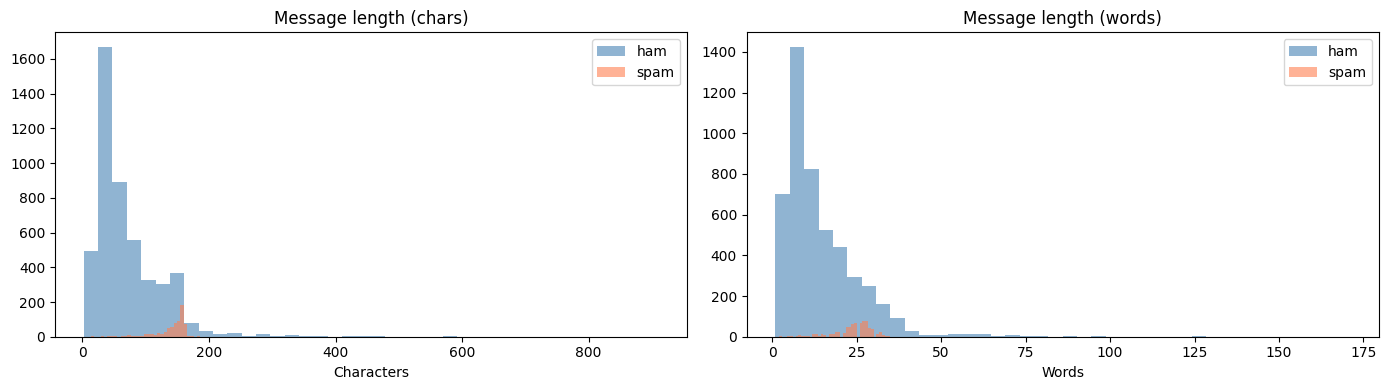

Spam tends to be longer — could be a useful feature on its own.


In [3]:
print('Class balance:')
print(df['label'].value_counts(normalize=True).round(3))
print(f'\nSpam fraction: {df.target.mean():.1%}  →  imbalanced. We need stratified split + careful metrics.')

df['len_chars'] = df['text'].str.len()
df['len_words'] = df['text'].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for label, color in [('ham', 'steelblue'), ('spam', 'coral')]:
    ax[0].hist(df[df.label==label].len_chars, bins=40, alpha=0.6, label=label, color=color)
    ax[1].hist(df[df.label==label].len_words, bins=40, alpha=0.6, label=label, color=color)
ax[0].set_xlabel('Characters'); ax[0].set_title('Message length (chars)'); ax[0].legend()
ax[1].set_xlabel('Words');      ax[1].set_title('Message length (words)'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Spam tends to be longer — could be a useful feature on its own.')

In [4]:
print('=== HAM examples ===')
for t in df[df.label=='ham'].text.head(3): print(' •', t)
print('\n=== SPAM examples ===')
for t in df[df.label=='spam'].text.head(3): print(' •', t)

=== HAM examples ===
 • Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
 • Ok lar... Joking wif u oni...
 • U dun say so early hor... U c already then say...

=== SPAM examples ===
 • Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
 • FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
 • WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


## Step 4–7: Build a text-cleaning function (the NLP preprocessing chain)

**The standard chain for English text classification:**
1. Lowercase — `Free` and `free` should be the same token.
2. Replace URLs / phone numbers / numbers with placeholders — they leak signal but the literal value is noise.
3. Strip HTML and non-letters (keep apostrophes for contractions).
4. Collapse whitespace.
5. Tokenize on whitespace.
6. Remove stop words — `the`, `is`, `a` carry little signal.
7. Stem (or lemmatize) — `running`, `runs`, `ran` → `run`.

**Task-specific tweaks:**
- For spam: keep numbers and `URL` placeholders — they're predictive.
- For sentiment: keep `not`, `no`, `never` — negation flips meaning.
- For BERT-style models: **don't** preprocess; the tokenizer handles it.

In [5]:
# Use NLTK if available; otherwise a tiny built-in stopword list and a Porter-style stemmer.
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    from nltk.corpus import stopwords as nltk_stop
    from nltk.stem import PorterStemmer, WordNetLemmatizer
    STOPWORDS = set(nltk_stop.words('english'))
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    HAS_NLTK = True
except Exception:
    HAS_NLTK = False
    STOPWORDS = set('a an the is are was were be been being of in on at to for with by and or but if it this that these those i you he she we they me him her us them my your his our their as'.split())
    stemmer = None
    lemmatizer = None

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
PHONE_RE = re.compile(r'\b\d{4,}\b')      # 4+ digits → likely phone / code
NUM_RE   = re.compile(r'\b\d+\b')
HTML_RE  = re.compile(r'<.*?>')
NONALPHA = re.compile(r"[^a-z\s']")
MULTISPACE = re.compile(r'\s+')

def clean_text(t: str, keep_negation: bool = False, do_stem: bool = True) -> str:
    t = t.lower()
    t = URL_RE.sub(' urltoken ', t)        # placeholder, signal stays
    t = HTML_RE.sub(' ', t)
    t = PHONE_RE.sub(' phonetoken ', t)
    t = NUM_RE.sub(' numtoken ', t)
    t = NONALPHA.sub(' ', t)
    t = MULTISPACE.sub(' ', t).strip()
    tokens = t.split()
    drop = STOPWORDS - {'not', 'no', 'never'} if keep_negation else STOPWORDS
    tokens = [w for w in tokens if w not in drop and len(w) > 1]
    if do_stem and stemmer is not None:
        tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

# Demo on a few messages
for t in df.text.head(3):
    print('ORIG :', t)
    print('CLEAN:', clean_text(t))
    print('-'*70)

ORIG : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
CLEAN: go jurong point crazi avail bugi great world la buffet cine got amor wat
----------------------------------------------------------------------
ORIG : Ok lar... Joking wif u oni...
CLEAN: ok lar joke wif oni
----------------------------------------------------------------------
ORIG : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
CLEAN: free entri numtoken wkli comp win fa cup final tkt st may phonetoken text fa phonetoken receiv entri question std txt rate c' appli 's
----------------------------------------------------------------------


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1007)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1007)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1007)>


**Why wrap it in a sklearn `Transformer`?** So we can put it inside a `Pipeline` and it gets fit/applied automatically during cross-validation — no leakage, no "forgot to clean the test set" bugs.

In [6]:
class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, keep_negation: bool = False, do_stem: bool = True):
        self.keep_negation = keep_negation
        self.do_stem = do_stem
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return [clean_text(t, self.keep_negation, self.do_stem) for t in X]

print('TextCleaner ready — drop into a Pipeline.')

TextCleaner ready — drop into a Pipeline.


## Step 8: Train/test split — with `stratify`

**Always stratify for classification with class imbalance.** Otherwise you can end up with a test set that has too few spam messages to evaluate properly.

In [7]:
X = df['text'].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)}  spam fraction: {y_train.mean():.3f}')
print(f'Test : {len(X_test)}   spam fraction: {y_test.mean():.3f}')

Train: 4457  spam fraction: 0.134
Test : 1115   spam fraction: 0.134


## Step 9: Build the full Pipeline (cleaner → vectorizer → model)

**Critical:** put the cleaner AND the vectorizer inside the Pipeline. Then `fit()` learns the vocabulary on the training fold only, and `predict()` on raw text does the right thing automatically — at inference time you just pass the raw SMS string.

In [8]:
def make_pipe(model):
    return Pipeline([
        ('clean',  TextCleaner(keep_negation=False, do_stem=True)),
        ('tfidf',  TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ('model',  model),
    ])

print('Pipeline factory ready. Same pipeline shape for any model.')

Pipeline factory ready. Same pipeline shape for any model.


## Step 10: Baseline — predict majority class

In [9]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred = dummy.predict(X_test)
print('Baseline — predict majority class (ham):')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1 (spam): {f1_score(y_test, y_pred):.4f}   ← 0, useless')
print('That 87% accuracy is meaningless. Always check F1 / recall on the minority class.')

Baseline — predict majority class (ham):
  Accuracy : 0.8664
  F1 (spam): 0.0000   ← 0, useless
That 87% accuracy is meaningless. Always check F1 / recall on the minority class.


## Step 11: Try several models — quick CV bake-off

In [10]:
candidates = {
    'Multinomial NB'      : MultinomialNB(),
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Linear SVM'          : LinearSVC(class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE, class_weight='balanced'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in candidates.items():
    pipe = make_pipe(model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f'{name:22s} | CV F1(spam) = {scores.mean():.4f} ± {scores.std():.4f}')

Multinomial NB         | CV F1(spam) = 0.9098 ± 0.0095
Logistic Regression    | CV F1(spam) = 0.9360 ± 0.0064
Linear SVM             | CV F1(spam) = 0.9554 ± 0.0061
Random Forest          | CV F1(spam) = 0.9409 ± 0.0098


## Step 12: Tune the winner with GridSearchCV

**Tip:** prefix grid keys with `'<step_name>__'` to reach into the pipeline. We'll tune both the vectorizer (`ngram_range`, `min_df`) and the model (`C`).

In [11]:
best_pipe = make_pipe(LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))

param_grid = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__min_df'      : [1, 2],
    'tfidf__max_df'      : [0.9, 0.95],
    'model__C'           : [0.5, 1.0, 5.0],
}

grid = GridSearchCV(best_pipe, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print(f'Best CV F1 : {grid.best_score_:.4f}')
final_model = grid.best_estimator_

Best params: {'model__C': 5.0, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Best CV F1 : 0.9486


## Step 13: Threshold tuning for imbalanced data

**Why:** `predict()` uses a fixed 0.5 cutoff on `predict_proba`. With imbalance, a different threshold can give much better precision/recall trade-off. Pick on the **PR curve**.

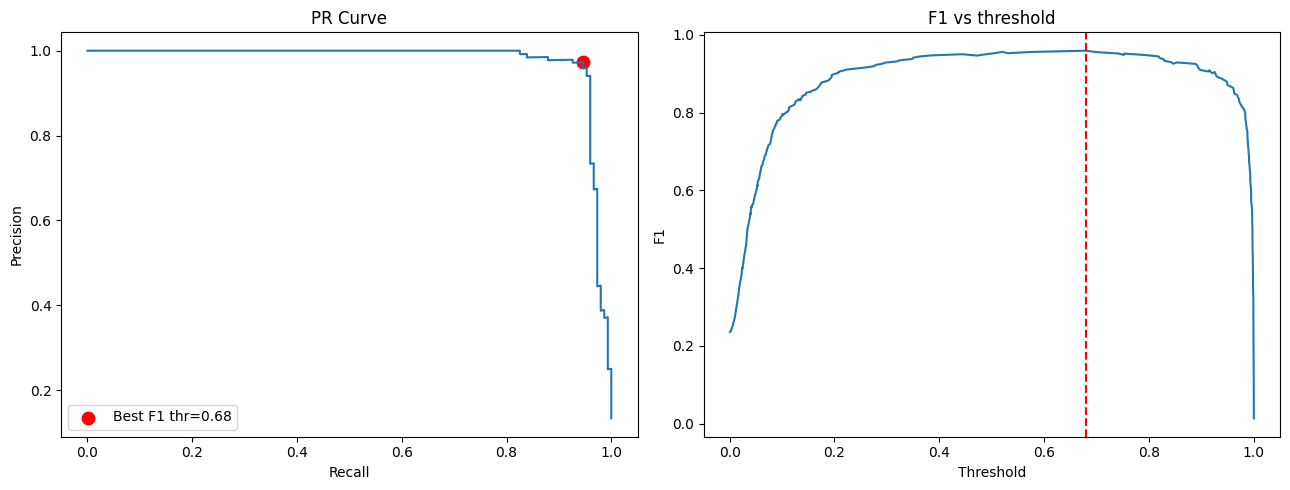

Default thr (0.5)       → F1 = 0.9530
Best thr (0.680)  → F1 = 0.9592


In [12]:
y_prob = final_model.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = int(np.argmax(f1s[:-1]))
best_thr = thr[best_i]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(rec, prec)
ax[0].scatter(rec[best_i], prec[best_i], color='red', s=80, label=f'Best F1 thr={best_thr:.2f}')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].set_title('PR Curve'); ax[0].legend()
ax[1].plot(thr, f1s[:-1])
ax[1].axvline(best_thr, color='red', ls='--')
ax[1].set_xlabel('Threshold'); ax[1].set_ylabel('F1'); ax[1].set_title('F1 vs threshold')
plt.tight_layout(); plt.show()

print(f'Default thr (0.5)       → F1 = {f1_score(y_test, (y_prob>=0.5).astype(int)):.4f}')
print(f'Best thr ({best_thr:.3f})  → F1 = {f1s[best_i]:.4f}')

## Step 14: Final evaluation — confusion matrix, ROC, classification report

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

ROC-AUC: 0.9910


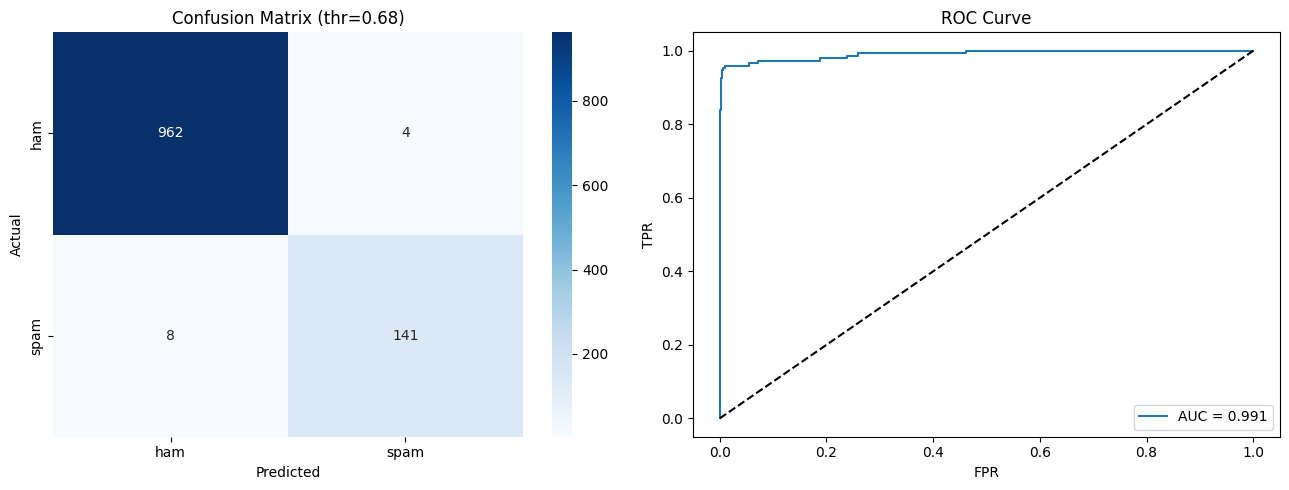

In [13]:
y_pred = (y_prob >= best_thr).astype(int)

print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=ax[0])
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual'); ax[0].set_title(f'Confusion Matrix (thr={best_thr:.2f})')

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC Curve'); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 15: Inspect mistakes — read the misclassified messages

**Why:** numbers don't tell you *what kind* of mistakes the model makes. Reading 10 false positives and 10 false negatives reveals patterns (e.g., "the model misses spam that doesn't have phone numbers") that drive the next improvement.

In [14]:
errors = pd.DataFrame({'text': X_test, 'actual': y_test, 'pred': y_pred, 'prob': y_prob})
fp = errors[(errors.actual==0) & (errors.pred==1)].sort_values('prob', ascending=False).head(5)
fn = errors[(errors.actual==1) & (errors.pred==0)].sort_values('prob').head(5)
print('=== False Positives (ham flagged as spam) ===')
for _, r in fp.iterrows():
    print(f"[p={r['prob']:.2f}]", r['text'][:120])
print('\n=== False Negatives (spam slipped through) ===')
for _, r in fn.iterrows():
    print(f"[p={r['prob']:.2f}]", r['text'][:120])

=== False Positives (ham flagged as spam) ===
[p=0.92] U 2.
[p=0.91] MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
[p=0.85] This is ur face test ( 1 2 3 4 5 6 7 8 9  &lt;#&gt;  ) select any number i will tell ur face astrology.... am waiting. q
[p=0.75] K..u also dont msg or reply to his msg..

=== False Negatives (spam slipped through) ===
[p=0.02] Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?
[p=0.04] Latest News! Police station toilet stolen, cops have nothing to go on!
[p=0.04] ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringi
[p=0.05] Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you respond you get fur
[p=0.10] Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 123


## Step 16: Explain the model — top features per class

For TF-IDF + Logistic Regression, the largest coefficients are the most spam-y / ham-y tokens.

In [15]:
tfidf  = final_model.named_steps['tfidf']
logreg = final_model.named_steps['model']
vocab  = np.array(tfidf.get_feature_names_out())
coefs  = logreg.coef_[0]

top_spam = vocab[np.argsort(coefs)[-15:][::-1]]
top_ham  = vocab[np.argsort(coefs)[:15]]
print('Top spam-indicative tokens:'); print(', '.join(top_spam))
print('\nTop ham-indicative tokens :'); print(', '.join(top_ham))

Top spam-indicative tokens:
phonetoken, urltoken, txt, numtoken, repli, uk, mobil, text, servic, rington, stop, sexi, tone, filthi, sm

Top ham-indicative tokens :
lt, gt, got, ll, ok, home, sorri, work, later, lor, hey, da, that, good, sir


## Step 17: Save the artifact

**The whole `Pipeline` is saved together** — TextCleaner + TF-IDF + LogisticRegression. At inference, you pass raw text and get a prediction. The threshold goes in metadata.

In [16]:
import sklearn
ART_DIR = 'artifacts_classification'
os.makedirs(ART_DIR, exist_ok=True)

with open(f'{ART_DIR}/spam_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
joblib.dump(final_model, f'{ART_DIR}/spam_model.joblib', compress=3)

metadata = {
    'model_name'   : 'sms-spam-tfidf-lr',
    'version'      : '1.0.0',
    'trained_at'   : datetime.utcnow().isoformat() + 'Z',
    'best_threshold': float(best_thr),
    'metrics'      : {
        'roc_auc' : float(roc_auc_score(y_test, y_prob)),
        'f1_spam' : float(f1_score(y_test, y_pred)),
        'precision_spam': float(((y_pred==1)&(y_test==1)).sum() / max(1,(y_pred==1).sum())),
        'recall_spam'   : float(((y_pred==1)&(y_test==1)).sum() / max(1,(y_test==1).sum())),
    },
    'best_params'  : {k: str(v) for k, v in grid.best_params_.items()},
    'env': {
        'python'  : sys.version.split()[0],
        'sklearn' : sklearn.__version__,
        'numpy'   : np.__version__,
        'pandas'  : pd.__version__,
    },
    'preprocessing_notes': 'lowercase, urltoken/phonetoken/numtoken substitution, stopword removal, Porter stemming',
}
with open(f'{ART_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(json.dumps(metadata, indent=2))

{
  "model_name": "sms-spam-tfidf-lr",
  "version": "1.0.0",
  "trained_at": "2026-05-31T19:12:59.026284Z",
  "best_threshold": 0.6795751298261997,
  "metrics": {
    "roc_auc": 0.9910236636236052,
    "f1_spam": 0.9591836734693876,
    "precision_spam": 0.9724137931034482,
    "recall_spam": 0.9463087248322147
  },
  "best_params": {
    "model__C": "5.0",
    "tfidf__max_df": "0.9",
    "tfidf__min_df": "1",
    "tfidf__ngram_range": "(1, 1)"
  },
  "env": {
    "python": "3.10.11",
    "sklearn": "1.2.2",
    "numpy": "1.23.5",
    "pandas": "1.4.4"
  },
  "preprocessing_notes": "lowercase, urltoken/phonetoken/numtoken substitution, stopword removal, Porter stemming"
}


## Step 18: Reload + smoke test

Pass raw SMS strings — no preprocessing on the caller side. The pipeline does it all.

In [17]:
loaded = joblib.load(f'{ART_DIR}/spam_model.joblib')
thr    = json.load(open(f'{ART_DIR}/metadata.json'))['best_threshold']

samples = [
    'Hey, are we still on for lunch tomorrow?',
    'CONGRATS! You won a free iPhone. Click http://bit.ly/xxx to claim now!',
    'Call me when you finish work',
    'URGENT! Your account has been suspended. Reply YES to reactivate. Charges apply.',
]
for s in samples:
    p = loaded.predict_proba([s])[0, 1]
    label = 'SPAM' if p >= thr else 'HAM'
    print(f'[{label}] (p={p:.3f}) {s}')

[HAM] (p=0.003) Hey, are we still on for lunch tomorrow?
[SPAM] (p=0.871) CONGRATS! You won a free iPhone. Click http://bit.ly/xxx to claim now!
[HAM] (p=0.007) Call me when you finish work
[HAM] (p=0.580) URGENT! Your account has been suspended. Reply YES to reactivate. Charges apply.


---
## Pipeline Recap — the NLP classification template

| # | Step | Notes |
|---|------|-------|
| 1 | Define problem | Cost asymmetry → which metric matters most |
| 2 | Load text | DataFrame with [label, text] |
| 3 | EDA | Class balance, lengths, sample messages |
| 4 | Clean text | Lowercase, URL/number tokens, strip punct |
| 5 | Tokenize | Whitespace split (or NLTK / SpaCy) |
| 6 | Stopwords | Remove — but keep negation for sentiment |
| 7 | Stem/Lemmatize | Porter stemming for classification |
| 8 | Stratified split | Always for imbalanced classification |
| 9 | Wrap in Pipeline | TextCleaner → TF-IDF → Model |
| 10 | Baseline | DummyClassifier — F1 should be ~0 |
| 11 | Bake-off | NB / LR / SVM / RF |
| 12 | Tune | GridSearchCV with `step__param` keys |
| 13 | Threshold | PR curve → pick best F1 (or business metric) |
| 14 | Final eval | Confusion matrix + ROC + classification report |
| 15 | Inspect FP/FN | Read mistakes — drives next iteration |
| 16 | Explain | Top coefficients per class |
| 17 | Save | joblib + pickle + metadata (incl. threshold) |
| 18 | Reload | Smoke test on raw text |

## Things to swap when you have a different text dataset

| If your data... | Change |
|-----------------|--------|
| Multilingual | Use language detection + per-language pipelines, or XLM-R |
| Longer documents (news) | `min_df` higher; bigrams less helpful, character n-grams for noisy text |
| Sentiment task | Set `keep_negation=True`; consider VADER as a baseline |
| Short noisy text (tweets) | Add emoji handling, `#hashtag` parsing, char n-grams |
| Many classes | Use `f1_macro` for CV, OvR/OvO not needed for LR |
| Need top accuracy | Replace TF-IDF + LR with a HuggingFace fine-tuned model |
| Heavy class imbalance | Add SMOTE inside `imblearn.pipeline.Pipeline`, or use `class_weight='balanced'` (already done here) |